# Procedimiento de solución al reto del sprint 6


## Paso 1. Abre el archivo de datos y estudia la información general 

In [219]:
import pandas as pd 
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plot
import math
import seaborn as sns
import json

df = pd.read_csv('../data/games.csv')

# Explorando datos de la tabla proporcionada
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [220]:
df.head()


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


## Paso 2. Prepara los datos

In [221]:
# Remplaza los nombres de las columnas (ponlos en minúsculas)
columns_names = [
    'name',
    'platform',
    'year_of_release',
    'genre',
    'na_sales',
    'eu_sales',
    'jp_sales',
    'other_sales',
    'critic_score',
    'user_score',
    'rating'
]
df.columns = columns_names

In [222]:
# Visualización de los  datos involucrado en la columna 'user_score' que reporta ser object
datos_string_en_user_score=df[~df['user_score'].astype(str).str.contains(r'[0-9]', na=False)]['user_score'].unique()
print()

In [223]:
#Convierte los datos en los tipos necesarios.
df['year_of_release'] = df['year_of_release'].astype('Int64')
df['user_score'].unique()
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')


### Describe las columnas en las que los tipos de datos han sido cambiados y explica por qué.

* En la columna year_of_release el tipo fue cambiado a Int64. Esto debido a que solo estamos manejando el año, no una fecha. Por este motivo, se ha pasado de tener un flotante a un entero sin aplicar un datetime format
* En la columna use escore se aplica un formato float64 debido a que la expiración nos sugiere un dato numero. Se emplea el método to_numeric con el parámetro errors='coerce' para dejar los valores NaN como NaN sin encontrar errores en el proceso.


### Si es necesario, elige la manera de tratar los valores ausentes:

*  ##### Explica por qué rellenaste los valores ausentes como lo hiciste o por qué decidiste dejarlos en blanco.
*  ##### ¿Por qué crees que los valores están ausentes? Brinda explicaciones posibles.
*  ##### Presta atención a la abreviatura TBD: significa "to be determined" (a determinar). Especifica cómo piensas manejar estos casos

In [224]:
print('Cuenta de valores en la columna name:')
print(df['name'].value_counts(dropna=False))
print('Cuenta de valores en la columna platform:')
print(df['platform'].value_counts(dropna=False))
print('Cuenta de valores en la columna year_of_release:')
print(df['year_of_release'].value_counts(dropna=False))
print('Cuenta de valores en la columna genre:')
print(df['genre'].value_counts(dropna=False))
print('Cuenta de valores en la columna na_sales:')
print(df['na_sales'].value_counts(dropna=False))
print('Cuenta de valores en la columna eu_sales:')
print(df['eu_sales'].value_counts(dropna=False))
print('Cuenta de valores en la columna jp_sales:')
print(df['jp_sales'].value_counts(dropna=False))
print('Cuenta de valores en la columna other_sales:')
print(df['other_sales'].value_counts(dropna=False))
print('Cuenta de valores en la columna critic_score:')
print(df['critic_score'].value_counts(dropna=False))
print('Cuenta de valores en la columna user_score:')
print(df['user_score'].value_counts(dropna=False))
print('Cuenta de valores en la columna rating:')
print(df['rating'].value_counts(dropna=False))


Cuenta de valores en la columna name:
name
Need for Speed: Most Wanted    12
Madden NFL 07                   9
FIFA 14                         9
LEGO Marvel Super Heroes        9
Ratatouille                     9
                               ..
New Super Mario Bros. Wii       1
Wii Play                        1
New Super Mario Bros.           1
Pokemon Red/Pokemon Blue        1
Wii Sports Resort               1
Name: count, Length: 11560, dtype: int64
Cuenta de valores en la columna platform:
platform
PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64
Cuenta de valores en la columna year_of_release:
year_of_relea

### Hipótesis

1. year_of_release
    Los datos pueden estar incluidos en la columna de name

2. critic_score:
    Los datos faltantes pueden ser rellenados con la mediana ya que puede haber valores atípicos de calificaciones registradas

3. user_score:
    Los valores faltantes pueden ser rellenados con la mediana. Muchos de los score de jugadores deben encontrarse del lado izquierdo de la muestra indicando que hay puntuaciones altas. Todos los jugadores hacen su mejor marca

4. rating:
    Los valores de rating pueden ser rellenados con la moda. AL contener registros tan antiguos podemos inferir que no fueron registrados en su debido momento

In [225]:
# Probando la hipótesis numero 1
name_count = df['name'].count()
year_of_release_nulls_count = df['year_of_release'].isna().sum()
regex_year =r'(\b(19|20)\d{2}\b)'
name_that_include_year = df['name'].str.contains(regex_year, regex=True, na=False).sum()

print(f"El número total de registros es: {name_count}")
print(f"El número de registros con año de lanzamiento nulo es: {year_of_release_nulls_count}")
print(f"EL numero de registros con años incluidos en el nombre es: {name_that_include_year}")


El número total de registros es: 16713
El número de registros con año de lanzamiento nulo es: 269
EL numero de registros con años incluidos en el nombre es: 867


C:\Users\Jose Cabrera\AppData\Local\Temp\ipykernel_23540\1747738940.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  name_that_include_year = df['name'].str.contains(regex_year, regex=True, na=False).sum()


La hipótesis 1 es parcialmente aceptada debido a que se encuentra una discrepancia en el conteo de datos. Hay mas  requisaros con años incluidos que nulos. Esto debido al os casos de juegos que contienen años en sus títulos. Ejemplo: 'FIFA 2006'

<function matplotlib.pyplot.show(close=None, block=None)>

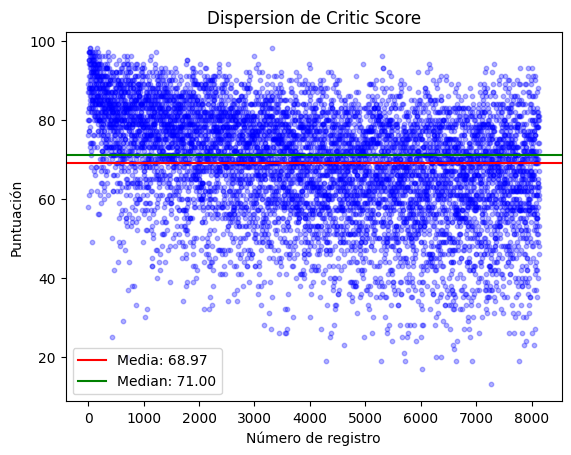

In [226]:
# Analizando con que valor poder controlar los Nan en critic_score
clean_critic_score = df['critic_score'].dropna()
plot.scatter(range(len(clean_critic_score)), clean_critic_score, alpha=0.3, s=10, c='blue')
plot.axhline(clean_critic_score.mean(), color='red', linestyle='-', label=f'Media: {clean_critic_score.mean():.2f}')
plot.axhline(clean_critic_score.median(), color='green', linestyle='-', label=f'Median: {clean_critic_score.median():.2f}')
plot.title('Dispersion de Critic Score')
plot.xlabel('Número de registro')
plot.ylabel('Puntuación')
plot.legend()
plot.show

Hipótesis 2 aceptada. Existen juegos con calificaciones de 10 y 20 (outliers), la media se ve afectada

<function matplotlib.pyplot.show(close=None, block=None)>

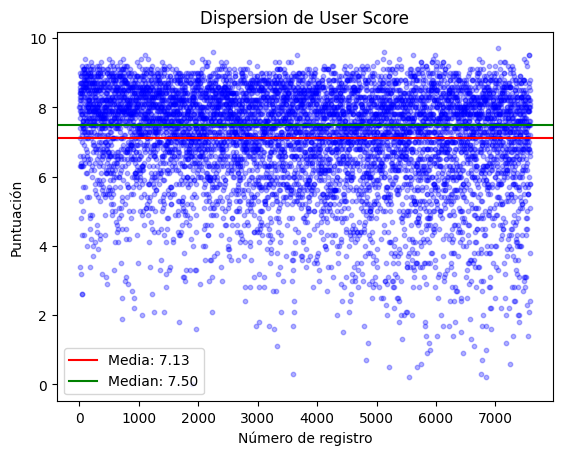

In [227]:
# Analizando con que valor poder controlar los Nan en user_score
clean_user_score = df['user_score'].dropna()
plot.scatter(range(len(clean_user_score)), clean_user_score, alpha=0.3, s=10, c='blue')
plot.axhline(clean_user_score.mean(), color='red', linestyle='-', label=f'Media: {clean_user_score.mean():.2f}')
plot.axhline(clean_user_score.median(), color='green', linestyle='-', label=f'Median: {clean_user_score.median():.2f}')
plot.title('Dispersion de User Score')
plot.xlabel('Número de registro')
plot.ylabel('Puntuación')
plot.legend()
plot.show

Hipótesis 3 aceptada.  Hay un sesgo a la izquierda por puntuaciones altas. El valor de la media se ve comprometido como valor de complementación

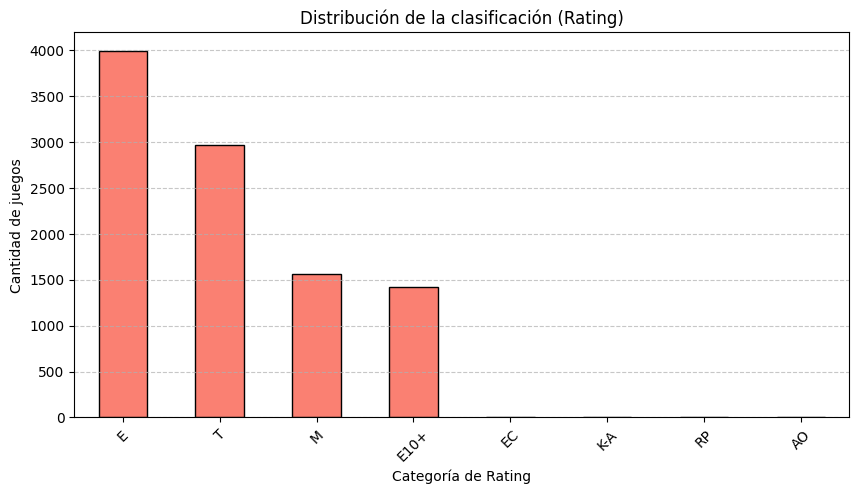

In [228]:
# Analizando con que valor poder controlar los Nan en rating
rating_counts = df['rating'].value_counts()
plot.figure(figsize=(10,5))
rating_counts.plot(kind='bar', color='salmon', edgecolor='black')

plot.title('Distribución de la clasificación (Rating)')
plot.xlabel('Categoría de Rating')
plot.ylabel('Cantidad de juegos')
plot.xticks(rotation=45)
plot.grid(axis='y', linestyle='--', alpha=0.7)

plot.show()

Hipótesis 4 aceptada Para datos cualitativos la moda es la única medida de tendencia. La gráfica muestra que los juegos de clasificación con mayor moda es la 'E'


In [229]:
# En el caso de los valores cualitativos no existe la media y la mediana. La forma más sana de rellenar los faltantes es con la moda
moda_rating = df['rating'].mode()[0]
print(f"La moda es: {moda_rating}")

La moda es: E


In [230]:
print(df[df['rating'].isna()])
print(f"Comprobación de que este grupo de datos con NaN no tiene todos los registros con NaN en user_score imprimiendo sus valores únicos:\n {df[df['rating'].isna()]['user_score'].unique()}")
print(f"Comprobación de que este grupo de datos con NaN no tiene todos los registros con NaN en critic_score imprimiendo sus valores únicos:\n {df[df['rating'].isna()]['critic_score'].unique()}")

                                name platform  year_of_release         genre  \
1                  Super Mario Bros.      NES             1985      Platform   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                             Tetris       GB             1989        Puzzle   
9                          Duck Hunt      NES             1984       Shooter   
10                        Nintendogs       DS             2005    Simulation   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

In [231]:
# Evaluando la posibilidad de rellenar los datos de rating con el valor correpondiente a la mediana de user_score o critic_score
print(df[(df['user_score'] >= 7.5) & (df['user_score'] < 7.6)]['rating'].unique())
print(df[(df['critic_score'] >= 75) & (df['critic_score'] < 75)]['rating'].unique())

['E' 'M' 'T' 'E10+' nan]
[]


In [232]:
print()

In [233]:
print(df[df['year_of_release'].isna()])

                                    name platform  year_of_release  \
183                      Madden NFL 2004      PS2             <NA>   
377                     FIFA Soccer 2004      PS2             <NA>   
456           LEGO Batman: The Videogame      Wii             <NA>   
475           wwe Smackdown vs. Raw 2006      PS2             <NA>   
609                       Space Invaders     2600             <NA>   
...                                  ...      ...              ...   
16373  PDC World Championship Darts 2008      PSP             <NA>   
16405                      Freaky Flyers       GC             <NA>   
16448                          Inversion       PC             <NA>   
16458        Hakuouki: Shinsengumi Kitan      PS3             <NA>   
16522                       Virtua Quest       GC             <NA>   

              genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
183          Sports      4.26      0.26      0.01         0.71          94.0   

In [234]:
# Comprobando si el los datos tienen trazabilidad para completar los faltantes cualitativos mediante columnas de su mismo registro. En este caso en particular se busca el nombre del juego en otras plataformas

print(df[df['name']=='LEGO Batman: The Videogame'])


                             name platform  year_of_release   genre  na_sales  \
397    LEGO Batman: The Videogame     X360             2008  Action      2.04   
456    LEGO Batman: The Videogame      Wii             <NA>  Action      1.80   
460    LEGO Batman: The Videogame       DS             2008  Action      1.75   
1519   LEGO Batman: The Videogame      PS3             2008  Action      0.72   
1538   LEGO Batman: The Videogame      PSP             <NA>  Action      0.57   
1553   LEGO Batman: The Videogame      PS2             2008  Action      0.72   
12465  LEGO Batman: The Videogame       PC             2008  Action      0.02   

       eu_sales  jp_sales  other_sales  critic_score  user_score rating  
397        1.02       0.0         0.32          76.0         7.9   E10+  
456        0.97       0.0         0.29          74.0         7.9   E10+  
460        1.01       0.0         0.29          72.0         8.0   E10+  
1519       0.39       0.0         0.19          75.0   

#### ***Conclusion***
La decisión tomada para los valor que contienen faltantes es la siguiente:

***1. Caso → NaN en year_of_release***

* Estandarizar el nombre de los juegos a minúsculas para no tener perder referencia de los valores a comprar
* Evaluar que registros incluyen el año en el name, recuperar el año de ese registro
* Buscar el año de release en juegos de otras plataformas que tengan el año definido por nombre del juego y evaluar que sea el año de lanzamiento en las demás plataformas sea único

***2. Caso → NaN en critic_score***

    Evaluando los datos, referiremos el valor de la mediana para rellenar los valores faltantes ya que la gráfica de dispersión muestra que tenemos valores atípicos en los registros.

***3. Caso → NaN en user_score***

    Evaluando los datos, referiremos el valor de la mediana para rellenar los valores faltantes ya que la gráfica de dispersión muestra que tenemos valores atípicos en los registros.

***4. Caso → NaN en rating***

    Evaluando los datos y tratándose de un valor cualitativo, referiremos el valor de la moda para rellenar los valores faltantes

    

In [235]:
# 1er caso → NaN en year_of_release

# Acción 1
# Estandarizar el nombre de los juegos y plataforma a minúsculas
df['name'] = df['name'].str.lower().str.strip()
df['platform'] = df['platform'].str.lower().str.strip()

# Acción 2
# Evaluar que registros incluyen el año en el name, recuperar el año de ese registro

# Empleamos un regex para buscar el año dentro de los nombres

regex_year =r'(\b(19|20)\d{2}\b)'

# Aplicaremos el regex solo a las filas donde year_of_release es nulo
mask_nulls = df['year_of_release'].isna()

# Extraeremos el año del nombre
extracted_years = df.loc[mask_nulls, 'name'].str.extract(regex_year)[0]

# Remplazamos los valores nulos por los años encontrados
df.loc[mask_nulls, 'year_of_release'] = df.loc[mask_nulls, 'year_of_release'].fillna(pd.to_numeric(extracted_years).astype('Int64'))



#Acción 3 
# Buscar el año de release en juegos de otras plataformas que tengan el año definido por nombre del juego y evaluar que sea el año de lanzamiento en las demás plataformas sea único

# Creación de un map con le año mas frecuente para cada nombre de juego
mapping_name_year= df.groupby('name')['year_of_release'].first()

# LLenar los nulos con el nombre del juego registrado en el map
df['year_of_release'] = df['year_of_release'].fillna(df['name'].map(mapping_name_year))



# Comprobación 
print(f"La suma de los registros nulos de year_of_release es: {df['year_of_release'].isna().sum()}")
conteo_final_sin_year=df[df['year_of_release'].isna()].groupby('name').size().sort_values(ascending=False)
print(f"El conteo final sin year es: \n {conteo_final_sin_year}")
print(f"Los registros sin year son: \n {df[df['year_of_release'].isna()]}")

# Se encuentra texto entre paréntesis como (jp sales) es necesario limpiarlos para saber que no y registro de donde sacar el año. Dejaremos el nombre solo por seguridad de la data y se abrirá una nueva columna para no perder los registros y comprobar
regex_text_between_parentesis = r'\(.*\)'
df['name_clean'] = df['name'].str.replace(regex_text_between_parentesis, '', regex=True).str.strip()
mapping_clean= df.groupby('name_clean')['year_of_release'].first()
df['year_of_release']= df['year_of_release'].fillna(mapping_clean)
print('-----------------------\n\n')
# Comprobación 
print(f"La suma de los registros nulos de year_of_release es: {df['year_of_release'].isna().sum()}")
final_count_without_year_clean=df[df['year_of_release'].isna()].groupby('name').size().sort_values(ascending=False)
print(f"El conteo final sin year es: \n {final_count_without_year_clean}")
print(f"Los registros sin year son: \n {df[df['year_of_release'].isna()]}")

# Al no tener forma de recuperar eso 139 registros faltantes se desestiman por comprometer análisis de datos en relación al año de lanzamiento
df['year_of_release'].dropna()

La suma de los registros nulos de year_of_release es: 139
El conteo final sin year es: 
 name
rock band                                     4
test drive unlimited 2                        3
backbreaker                                   2
port royale 3                                 2
robert ludlum's the bourne conspiracy         2
                                             ..
yakuza 4                                      1
yoostar on mtv                                1
yu yu hakusho: dark tournament                1
yu-gi-oh! 5d's wheelie breakers (jp sales)    1
zero: tsukihami no kamen                      1
Length: 127, dtype: int64
Los registros sin year son: 
                                            name platform  year_of_release  \
627                                   rock band     x360             <NA>   
657    frogger's adventures: temple of the frog      gba             <NA>   
805                                   rock band      wii             <NA>   
1142          

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16710    2016
16711    2006
16712    2016
16713    2003
16714    2016
Name: year_of_release, Length: 16576, dtype: Int64

In [236]:
# 2° Caso → NaN en critic score

# Calcular la mediana para completar los datos nulos

critic_score_median = df['critic_score'].median()
df['critic_score'] = df['critic_score'].fillna(critic_score_median)

# Comprobación

df['critic_score'].isna().sum()

np.int64(0)

In [237]:
# 3er Caso → NaN en user score

user_score_median = df['user_score'].median()
df['user_score'] = df['user_score'].fillna(user_score_median)

# Comprobación 

df['user_score'].isna().sum()



np.int64(0)

In [238]:
#4° Caso → NaN en rating

rating_mode = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(rating_mode)

# Comprobación 

df['rating'].isna().sum()


np.int64(0)

In [239]:
# Limpieza final de los registros
df.dropna(inplace=True)


### ***Resumen***

* Explica por qué rellenaste los valores ausentes como lo hiciste o por qué decidiste dejarlos en blanco.
    
    Los valores fueron rellenados con las consideraciones y estudios realizados anteriormente

* ¿Por qué crees que los valores están ausentes? Brinda explicaciones posibles.

    En el caso de year_of_release → 
        
                Puede estar relacionado con una captación de datos errónea. Hay datos ausentes en la columna name o que no fueron tomados al momento del registro.
                Puede tener relación con falta de normalización de datos. Al no tener trazabilidad entre plataformas podemos inferir que esos juego no tuvieron oportunidad de registrar el año de lanzamiento
                La data maneja registro de juegos retro puede se un problema de legacy por datos heredados en los años de documentation on digital


    En el caso del critic_score → 

                Parece que son datos faltantes al momento del registro, pues se contaba con datos por definir
                Efecto TBD, el usuario jamás emitió una valoración par el juego
                Al tratarse de juegos antiguos no se cuenta con este tipo de datos en visiones del pasado

    En el caso de user_score → 
        
                Parece que son datos faltantes al momento del registro , pues se contaba con datos por definir
                Efecto TBD, el usuario jamás emitió una valoración par el juego
                Al tratarse de juegos antiguos no se cuenta con este tipo de datos en visiones del pasado


    En el caso de rating → 
        
                Parece que son datos faltantes al momento del registro , pues se contaba con datos por definir
                En el caso de que un juego sea muy antiguo es posible no encontrar evaluación estadísticas
                Al tratarse de juegos antiguos no se cuenta con este tipo de datos en visiones del pasado



* Presta atención a la abreviatura TBD: significa "to be determine

    Que el usuario no ha emitido un calificación al momento de recolección de la muestra

* Al no tener una forma de estimar los valores faltantes podemos descartar los valores faltantes con un dropna




In [240]:
# Crear una función para definir el perfil de usuario de cada región de 2012 a 2016

regions = ['na_sales', 'eu_sales', 'jp_sales']

def create_user_profile(df, regions):
    profile = {}
    for region in regions:
        top_five_platforms= df.groupby('platform')[region].sum().sort_values(ascending=False).head(5).index.tolist()
        top_genres = df.groupby('genre')[region].sum().sort_values(ascending=False).head(5).index.tolist()
        top_titles = df.groupby('name')[region].sum().sort_values(ascending=False).head(5).index.tolist()
        top_rating = df.groupby('rating')[region].sum().sort_values(ascending=False).head(5).index.tolist()
        profile[region] = {'top_platforms': top_five_platforms, 'top_genres': top_genres, 'top_titles': top_titles, 'top_rating': top_rating}
    return profile
user_profiles = create_user_profile(set_platforms_projection_in_2017, regions)
print(json.dumps(user_profiles, indent=4))

{
    "na_sales": {
        "top_platforms": [
            "ps4",
            "xone",
            "x360",
            "ps3",
            "3ds"
        ],
        "top_genres": [
            "Action",
            "Shooter",
            "Sports",
            "Role-Playing",
            "Misc"
        ],
        "top_titles": [
            "grand theft auto v",
            "call of duty: ghosts",
            "call of duty: black ops 3",
            "minecraft",
            "call of duty: advanced warfare"
        ],
        "top_rating": [
            "E",
            "M",
            "E10+",
            "T"
        ]
    },
    "eu_sales": {
        "top_platforms": [
            "ps4",
            "ps3",
            "xone",
            "x360",
            "3ds"
        ],
        "top_genres": [
            "Action",
            "Shooter",
            "Sports",
            "Role-Playing",
            "Racing"
        ],
        "top_titles": [
            "grand theft auto v",
         

## Paso 3. Analiza los datos

In [241]:
# Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?

# Aseguramos que la data este limpia
df.info()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 16574 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16574 non-null  object 
 1   platform         16574 non-null  object 
 2   year_of_release  16574 non-null  Int64  
 3   genre            16574 non-null  object 
 4   na_sales         16574 non-null  float64
 5   eu_sales         16574 non-null  float64
 6   jp_sales         16574 non-null  float64
 7   other_sales      16574 non-null  float64
 8   critic_score     16574 non-null  float64
 9   user_score       16574 non-null  float64
 10  rating           16574 non-null  object 
 11  name_clean       16574 non-null  object 
dtypes: Int64(1), float64(6), object(5)
memory usage: 1.7+ MB


np.int64(0)

In [242]:
df.groupby('year_of_release')['year_of_release'].count()

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      42
1992      43
1993      60
1994     122
1995     219
1996     263
1997     289
1998     380
1999     339
2000     351
2001     485
2002     843
2003     785
2004     766
2005     949
2006    1021
2007    1203
2008    1440
2009    1431
2010    1269
2011    1154
2012     662
2013     548
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64

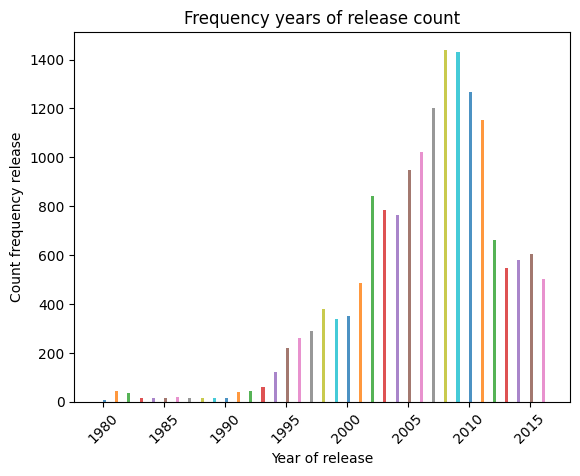

In [243]:
df.groupby('year_of_release')['year_of_release'].plot(kind='hist', bins=4, alpha= 0.8)
plot.title('Frequency years of release count')
plot.xlabel('Year of release')
plot.ylabel('Count frequency release')
plot.xticks(rotation=45)
plot.show()

##### Resultado

Los datos presentan bloque que no son estilísticamente  significativos para comprarlos con el resto. Un solo juego que se vendiera con mayor frecuencia en 1980 alteraría el promedio de ese año

Se puede apreciar lo siguiente:

* 1980 -1993: El volumen de lanzamientos es muy bajo (50 -100 por año). Esto no permite un anales de datos robusto
* 1994 - 2005: Se observa un aumento constante
* 2006 - 2011: Se observa el pico del dataset
* 2012 - 2016: Declive del data set



Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?


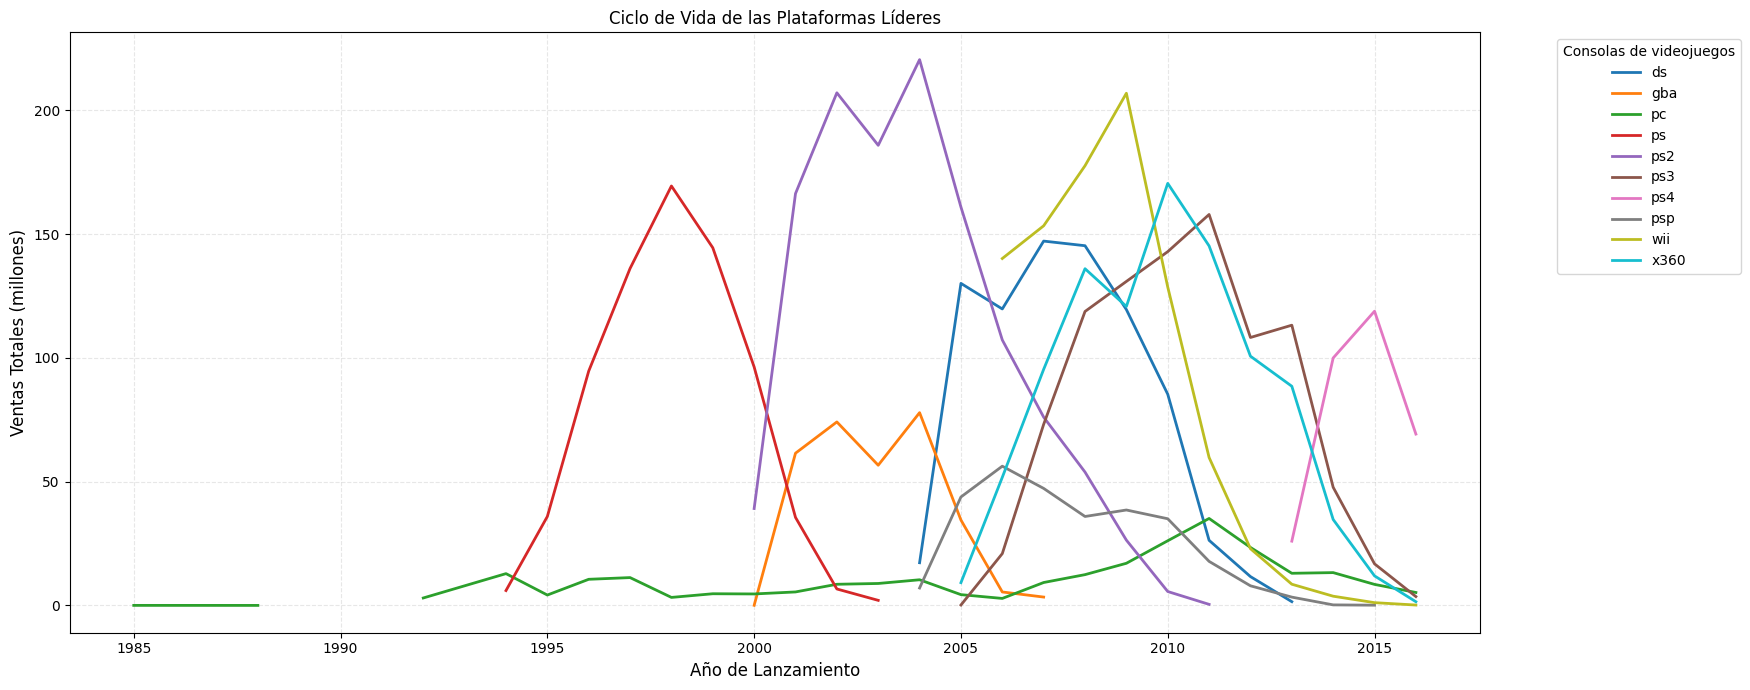

In [244]:
# Conocimiento de las ventas totales: na_sales + eu_sales + jp_sales +other_sales

df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

# Obtención del top 10 por ventas totales 
top_ten_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10).index

# Filtrar el dataframe para esas 10 plataformas
df_top_platform_sales = df[df['platform'].isin(top_ten_platforms)]

# Visualization de una tabla dinámica de ventas por año y plataforma

pivot_platforms = df_top_platform_sales.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')

# Graficar
pivot_platforms.plot(figsize=(15, 7), linewidth=2)
plot.title('Ciclo de Vida de las Plataformas Líderes')
plot.ylabel('Ventas Totales (millones)',fontsize=12)
plot.xlabel('Año de Lanzamiento', fontsize=12)
plot.ticklabel_format(axis='both')
plot.grid(True, linestyle='--', alpha=0.3)
plot.tight_layout()
plot.legend(title='Consolas de videojuegos', bbox_to_anchor=(1.05, 1), loc='upper left')
plot.show()






#### Resultado

1. Plataformas con mas ventas que ahora no tienen PS2, Wii, PS
2. Las Plataforma se tardan en aparecer 1 a 2 años posterior a la caída de ventas de una plataforma anterior.
2. 2.2 Las plataformas tardan en desaparecer de 7 a 10 años antes de una caída considerable en sus ventas.


Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.
* Derivado del analysis anterior  de años de lanzamiento se seleccionaría el  intervalo de 2012- 2016

Trabaja solo con los datos que consideras relevantes. Ignora los datos de años anteriores.

¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables

                                name platform  year_of_release       genre  \
0                         wii sports      wii             2006      Sports   
2                     mario kart wii      wii             2008      Racing   
3                  wii sports resort      wii             2009      Sports   
7                           wii play      wii             2006        Misc   
8          new super mario bros. wii      wii             2009    Platform   
...                              ...      ...              ...         ...   
16707               aiyoku no eustia      psv             2014        Misc   
16710  samurai warriors: sanada maru      ps3             2016      Action   
16711               lma manager 2007     x360             2006      Sports   
16712        haitaka no psychedelica      psv             2016   Adventure   
16714            winning post 8 2016      psv             2016  Simulation   

       na_sales  eu_sales  jp_sales  other_sales  critic_score 

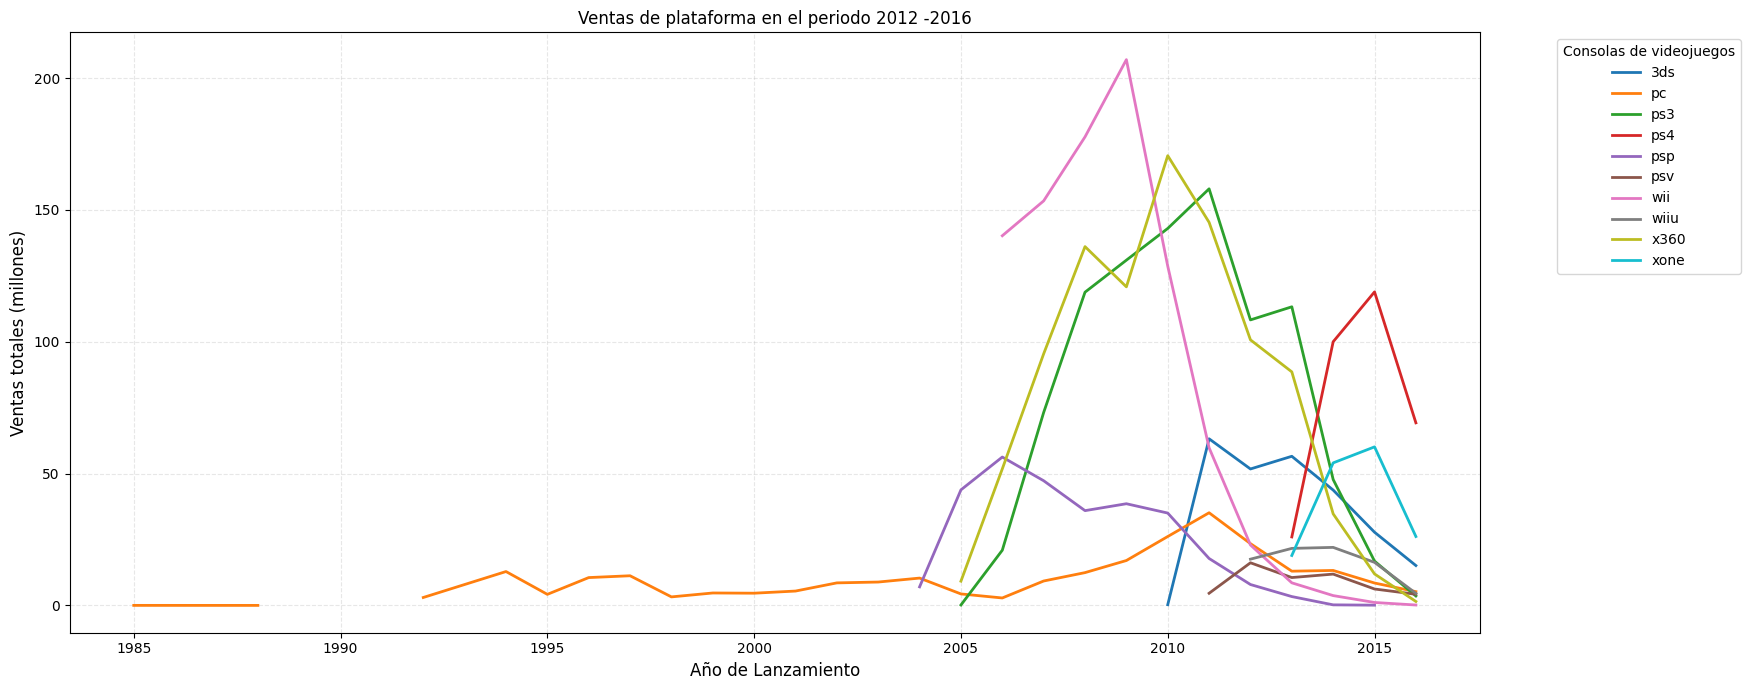

In [245]:
set_platforms_projection_in_2017 = df[df['year_of_release']>2012]
top_ten_platforms = set_platforms_projection_in_2017.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10).index
df_top_platform_sales_in_2017 = df[df['platform'].isin(top_ten_platforms)]
print(df_top_platform_sales_in_2017)
pivot_platforms = df_top_platform_sales_in_2017.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')
# Graficar
pivot_platforms.plot(figsize=(15, 7), linewidth=2)
plot.title('Ventas de plataforma en el periodo 2012 -2016')
plot.ylabel('Ventas totales (millones)',fontsize=12)
plot.xlabel('Año de Lanzamiento', fontsize=12)
plot.ticklabel_format(axis='both')
plot.grid(True, linestyle='--', alpha=0.3)
plot.tight_layout()
plot.legend(title='Consolas de videojuegos', bbox_to_anchor=(1.05, 1), loc='upper left')
plot.show()


### Resultado

Las plataformas que son lideres en las ventas son  PS4 y XOne

Las plataformas que crecen podría tener un grado alto de incertidumbre. Sería mejor tomarlo en cuneta coom las plataformas que se mantienen como lideres PS4 y XOnw

Las plataformas que se podrías elegir como plataformas rentables son:
* PS4
* Xone 
* 3DS 
* PC



Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

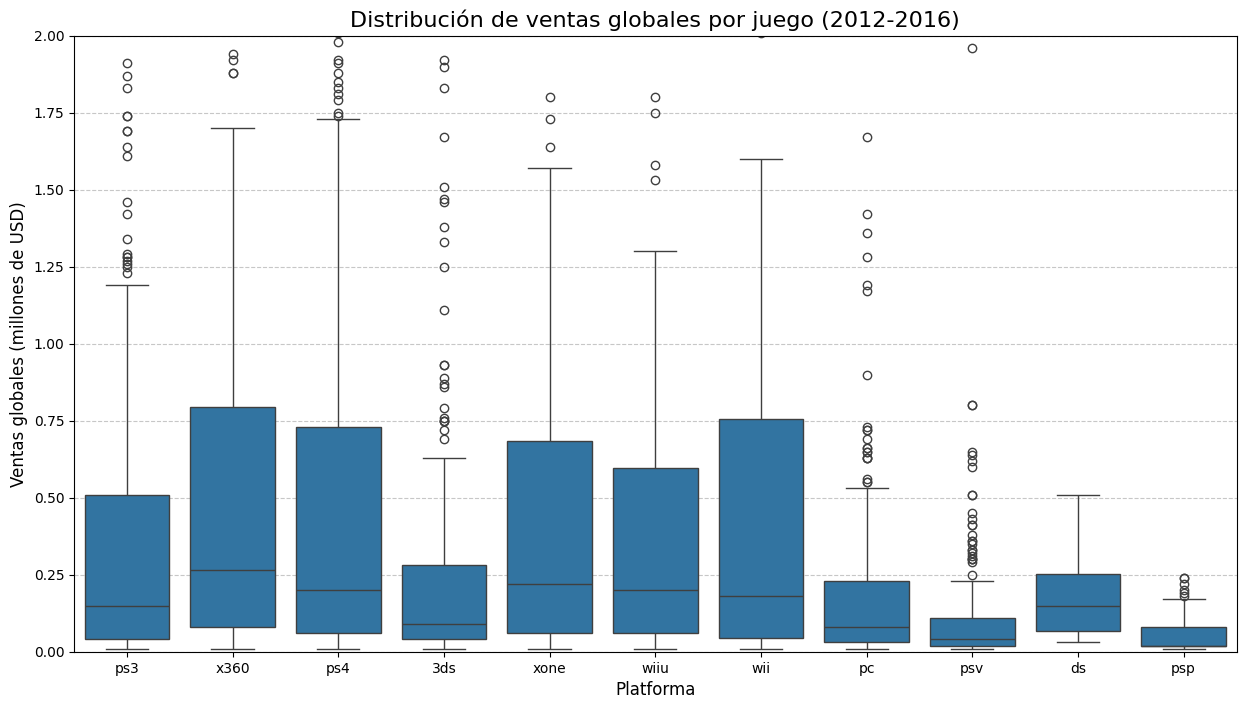

In [246]:
# Creando el diagrama de caja para los datos de las ventas globales de cada juego



plot.figure(figsize=(15,8))

sns.boxplot(data=set_platforms_projection_in_2017, x='platform', y='total_sales')
plot.ylim(0,2)
plot.title('Distribución de ventas globales por juego (2012-2016)', fontsize=16)
plot.xlabel('Platforma', fontsize=12)
plot.ylabel('Ventas globales (millones de USD)', fontsize=12)
plot.grid(axis='y', linestyle='--', alpha=0.7)
plot.show()

#### Hallazgos 

* ***¿Son significativas las diferencias en las ventas?***

Las ventas tienen diferencias significativas en volumen de ventas. Las plataformas presentan una mediana muy similar (entre 0.1 y 0.2 millones).
La diferencia radica en en los valores atípicos. Algunas de las plataformas como la PS$ tienen una gran cantidad de puntos por encima del bite superior, lo que indica que, aunque la plataforma promedia vende poco, estas plataformas tienen mayor capacidad para generar ventas altas.

* ***¿Qué sucede con las ventas promedio en varias plataformas?***

En casi todas la plataformas la media será mas alta que la mediana. Esto es porque presenta una distribution de larga cola. Unos pocos juegos venden decenas de millines mientras que miles de juegos venden casi nada.
En el caso de la x360, pps4, wii, y xone, presentan cajas mas altas. Esto sugiere una venta de juegos más saludable y un juego lanzado en estas plataformas tiene mayor probabilidad estadística de éxito.

Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.

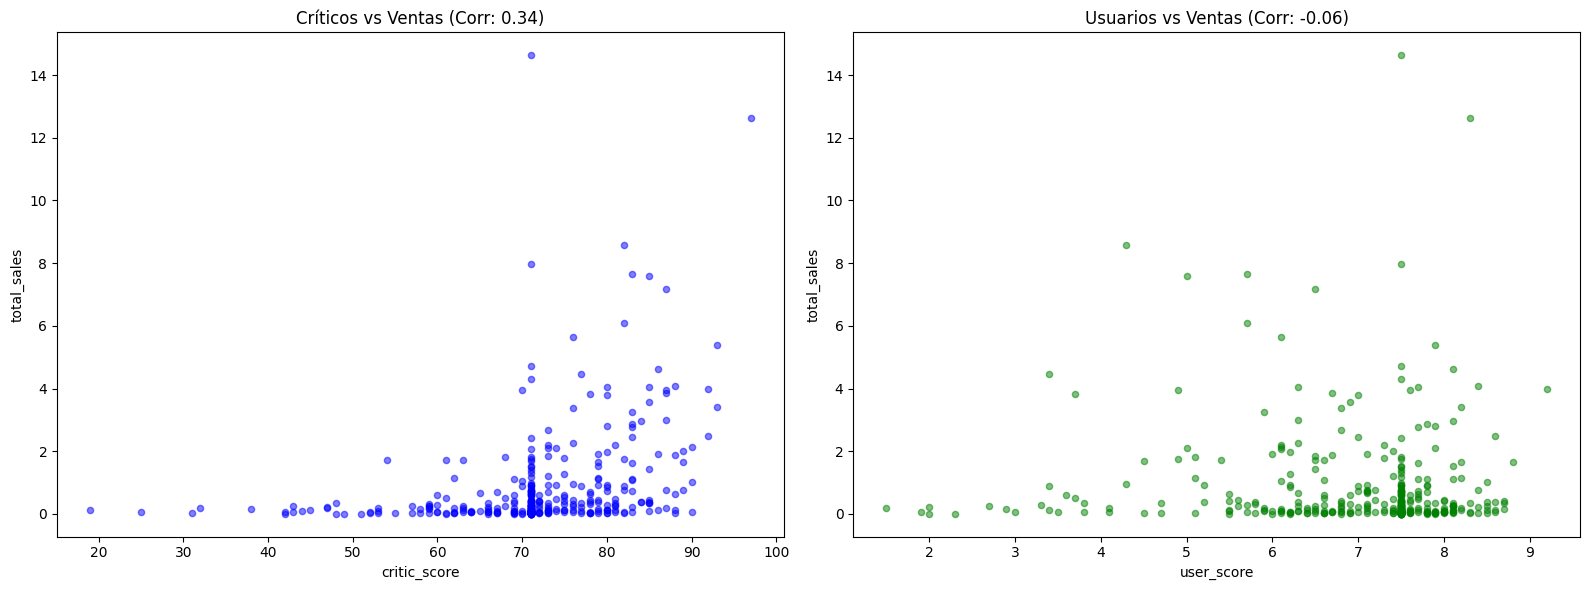

Correlación Críticos: 0.3387064530024636
Correlación Usuarios: -0.06275557891282794


In [247]:
# Creación de diagrama de dispersion para la plataforma PS4


# 1. Preparación de datos (Filtro correcto y limpieza de tipos). Usamos el periodo relevante 2012-2016 que definiste antes
ps4_df = df.loc[(df['platform'] == 'ps4') & (df['year_of_release'] >= 2012)]

# Convertimos user_score a número (por si hay 'tbd')
ps4_df.loc[:, 'user_score'] = pd.to_numeric(ps4_df['user_score'], errors='coerce')

# 2. Cálculo de correlaciones (Lo solicitado específicamente)
corr_critic = ps4_df['total_sales'].corr(ps4_df['critic_score'])
corr_user = ps4_df['total_sales'].corr(ps4_df['user_score'])

# 3. Gráficos de dispersión
fig, (ax1, ax2) = plot.subplots(1, 2, figsize=(16, 6)) # https://matplotlib.org/stable/api/figure_api.html#module-matplotlib.figure, https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html#matplotlib.pyplot.subplots → Documentation de figure y subplots

# Críticos
ps4_df.plot(x='critic_score', y='total_sales', kind='scatter', alpha=0.5, ax=ax1, color='blue')
ax1.set_title(f'Críticos vs Ventas (Corr: {corr_critic:.2f})')

# Usuarios
ps4_df.plot(x='user_score', y='total_sales', kind='scatter', alpha=0.5, ax=ax2, color='green')
ax2.set_title(f'Usuarios vs Ventas (Corr: {corr_user:.2f})')

plot.tight_layout()
plot.show()

print(f"Correlación Críticos: {corr_critic}")
print(f"Correlación Usuarios: {corr_user}")

Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

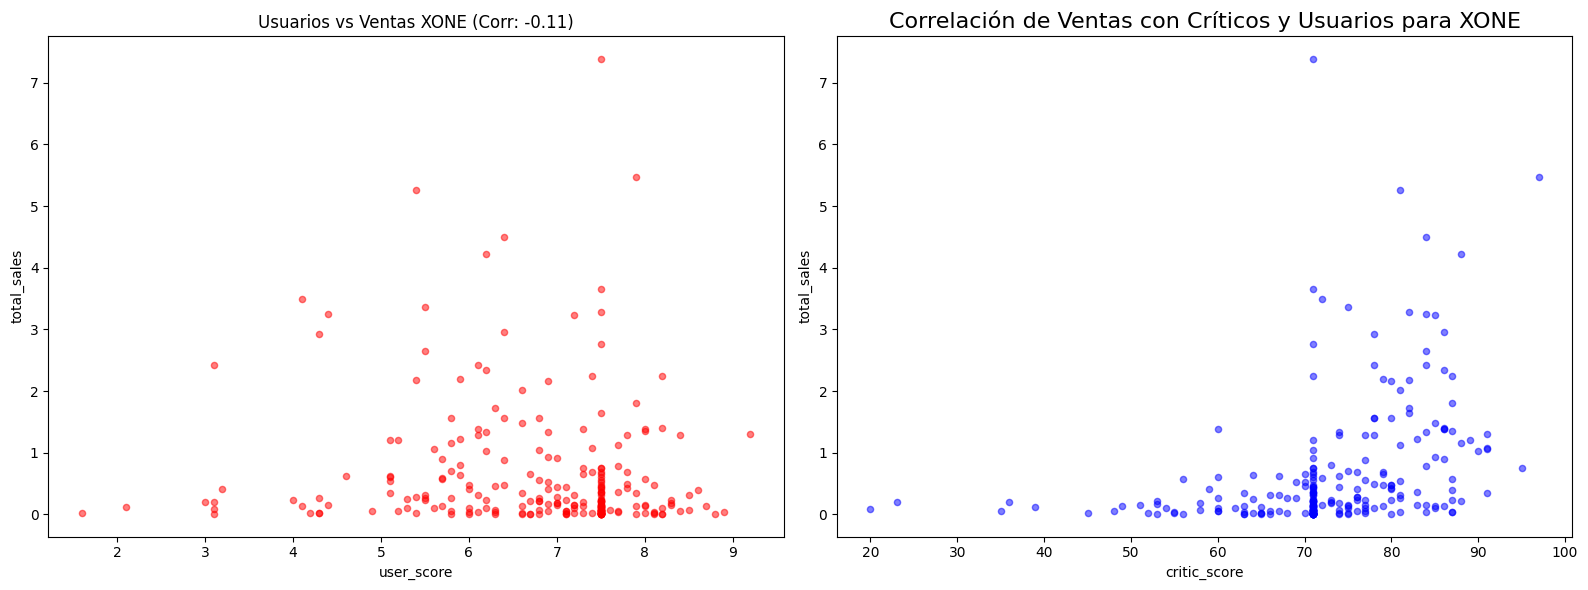

Correlación Usuarios XONE: -0.1059371810320923
Correlación Críticos XONE: 0.3604509779444024


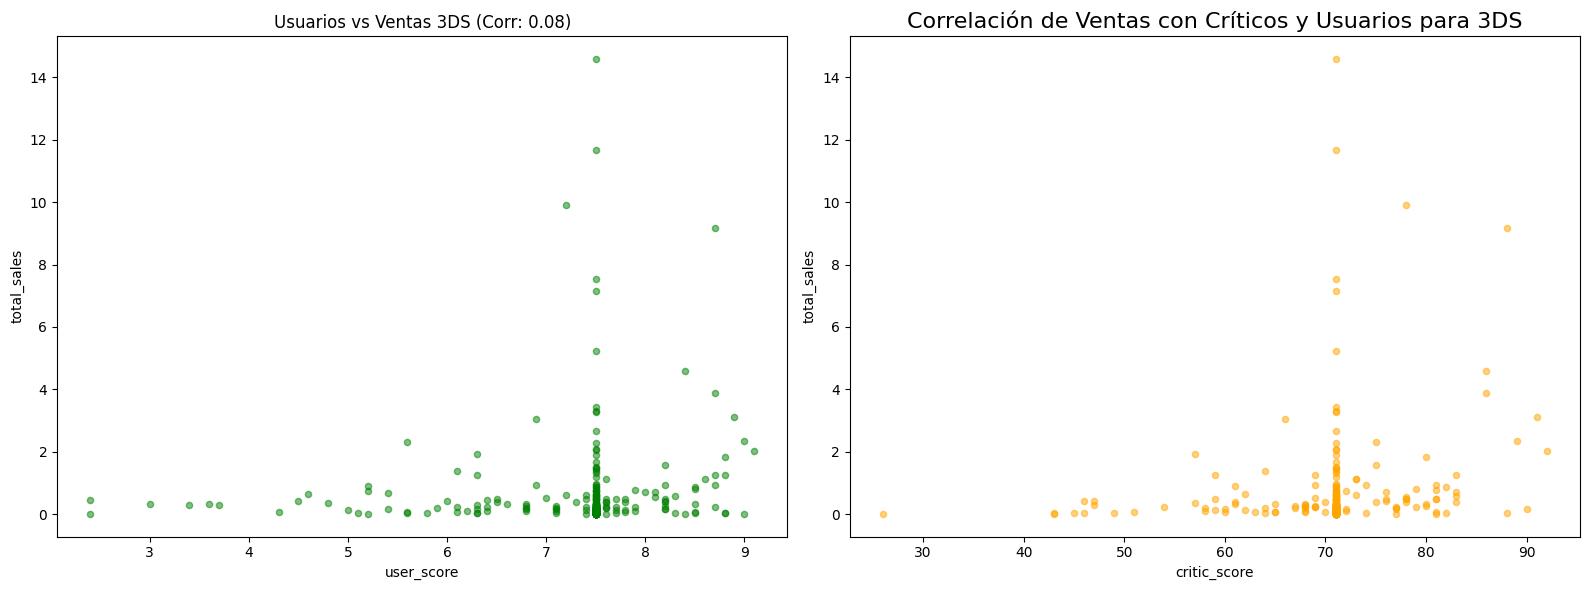

Correlación Usuarios 3DS: 0.07657665360098759
Correlación Críticos 3DS: 0.16341253485526483


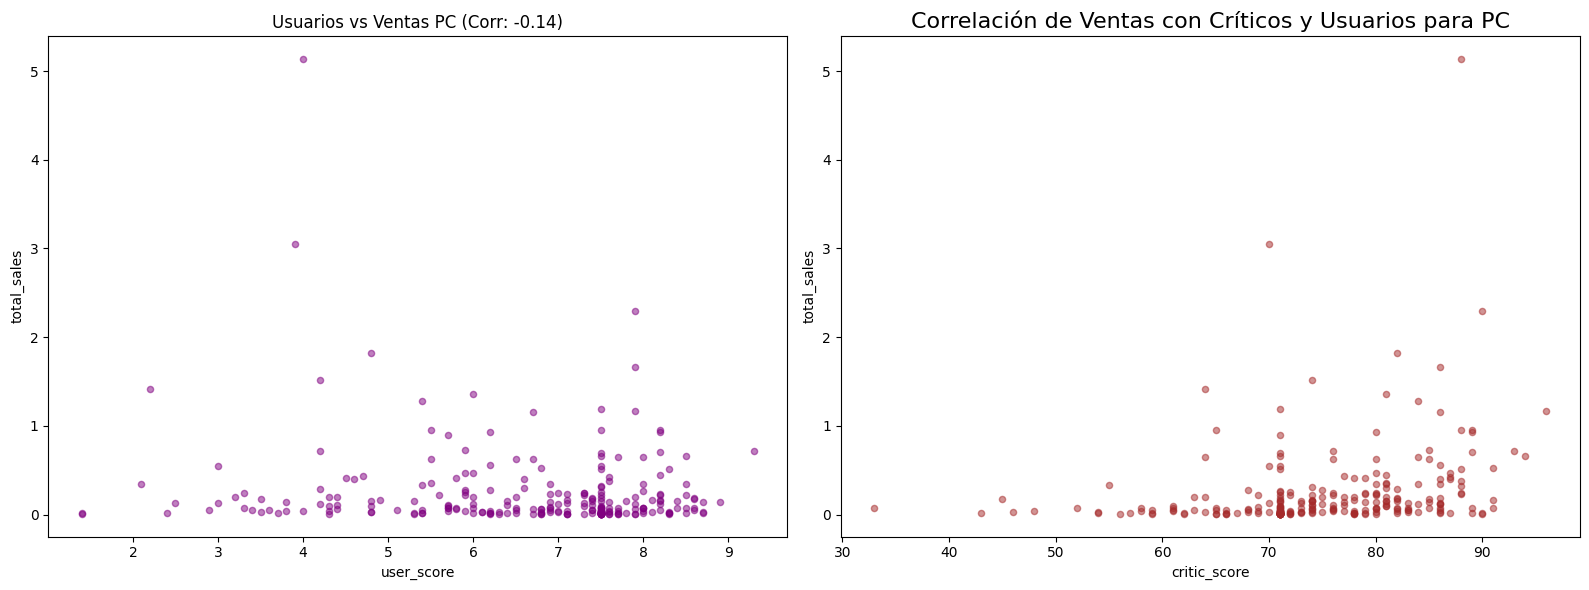

Correlación Usuarios PC: -0.1439955546738201
Correlación Críticos PC: 0.2570419893550913


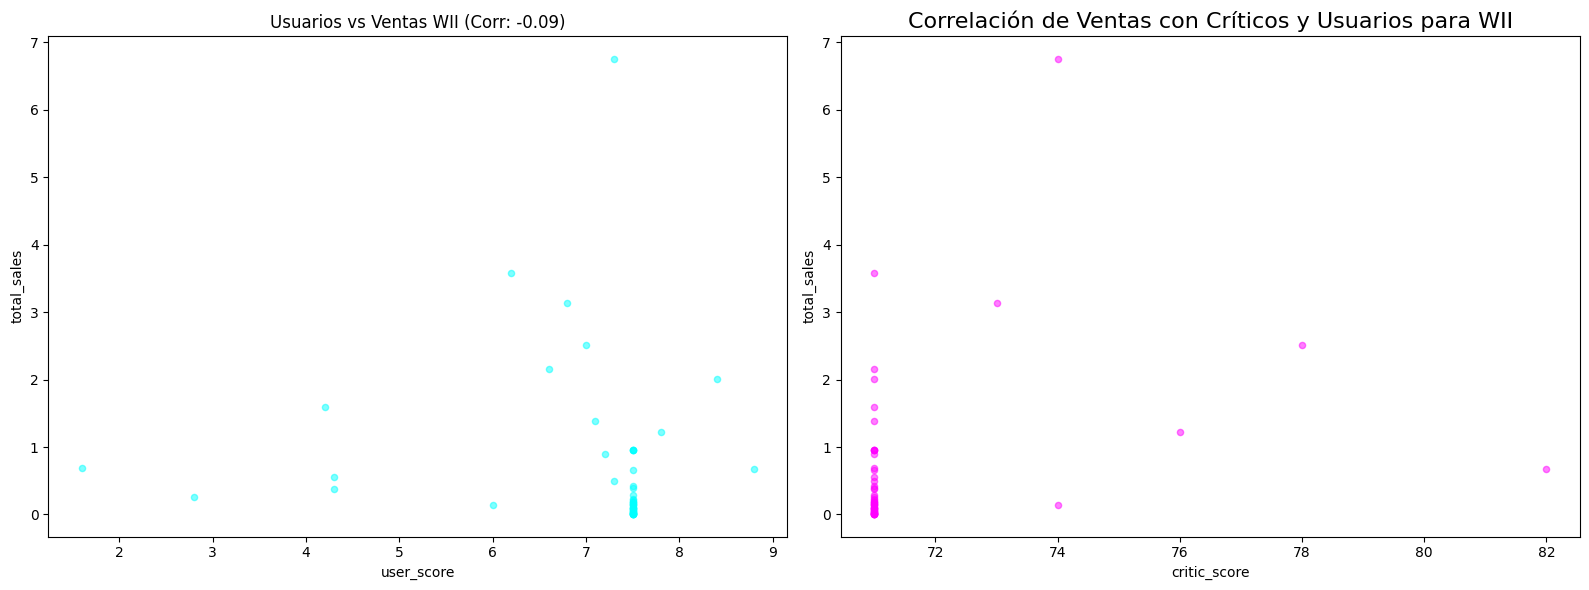

Correlación Usuarios WII: -0.09112703897974096
Correlación Críticos WII: 0.3130327180136747


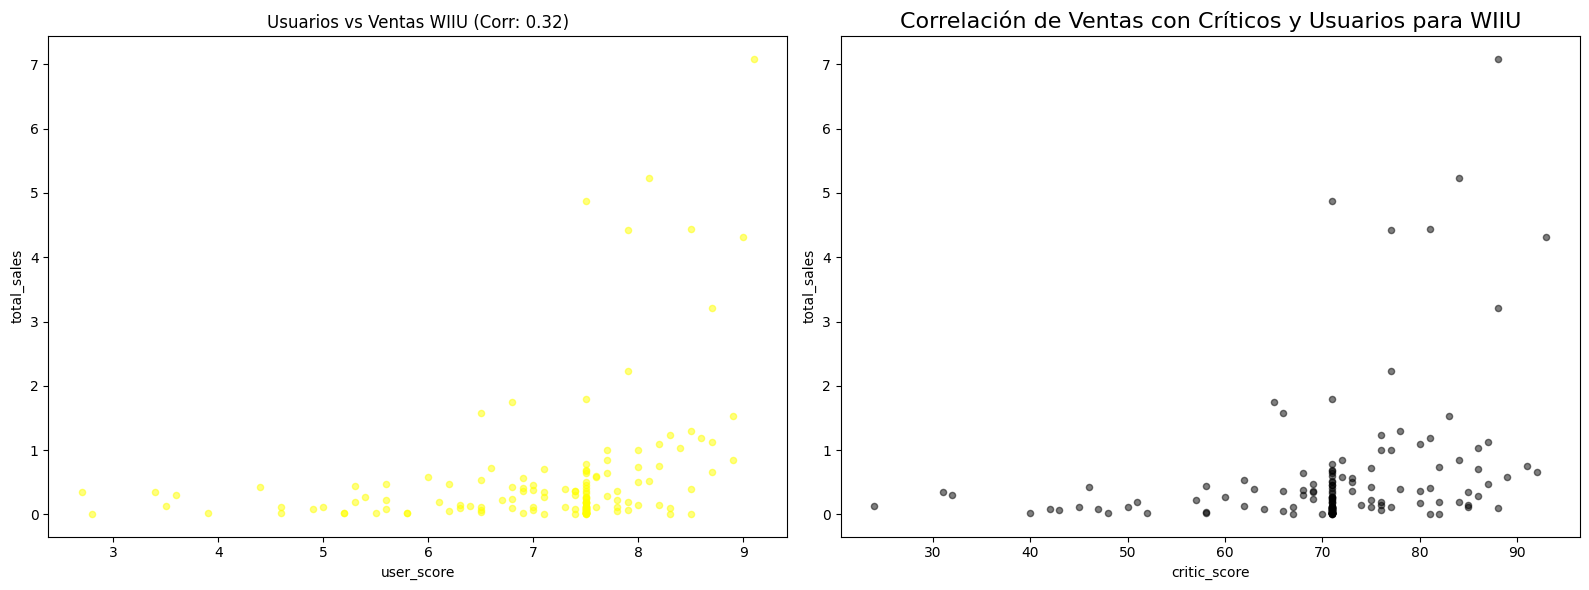

Correlación Usuarios WIIU: 0.3167223658488301
Correlación Críticos WIIU: 0.3083308926301158


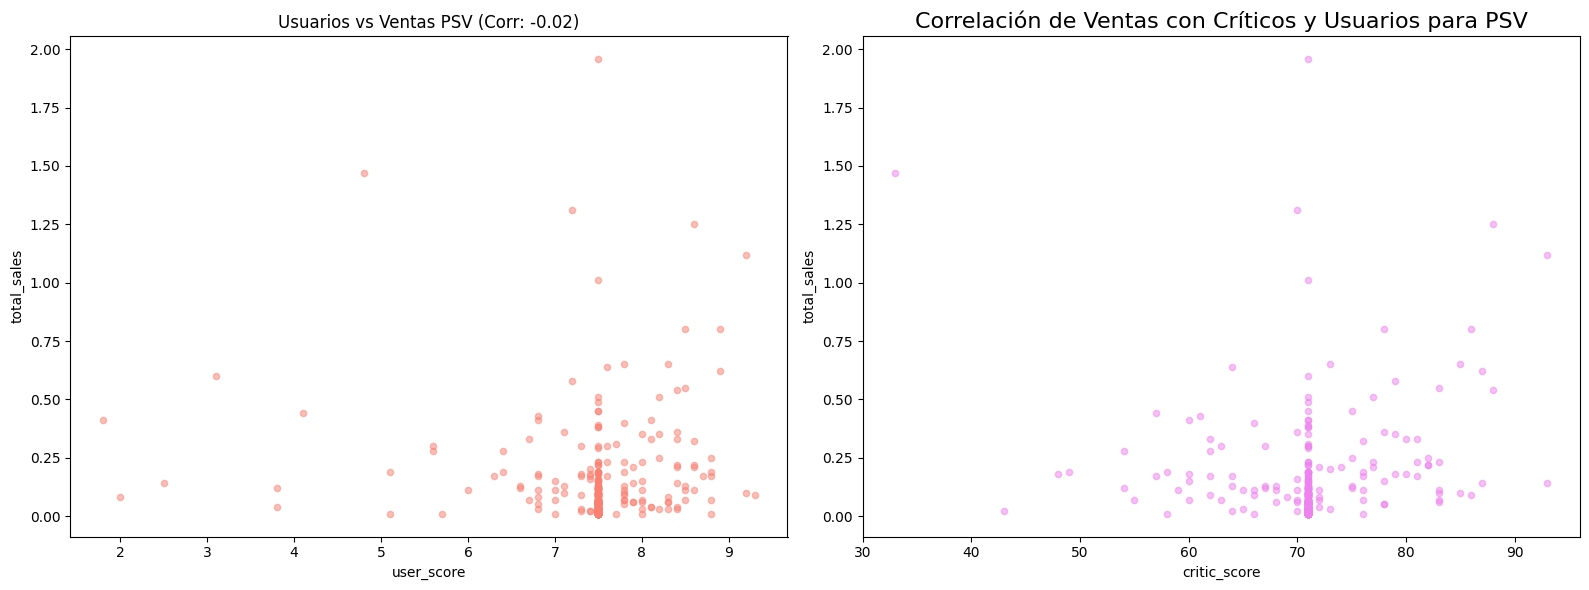

Correlación Usuarios PSV: -0.024027895466819077
Correlación Críticos PSV: 0.07456971551768383


In [261]:
# Calculando la correlación y creando los gráficos de dispersión para la plataforma Xbox one
platforms = [
    {
        'platform_name': 'xone',
        'color_user': 'red',
        'color_critic': 'blue'
    },
    {
        'platform_name': '3ds',
        'color_user': 'green',
        'color_critic': 'orange'
    },
    {
        'platform_name': 'pc',
        'color_user': 'purple',
        'color_critic': 'brown'
    },
    {
        'platform_name': 'wii',
        'color_user': 'cyan',
        'color_critic': 'magenta'
    },
    {
        'platform_name': 'wiiu',
        'color_user': 'yellow',
        'color_critic': 'black'
    },
    {
        'platform_name': 'psv',
        'color_user': 'salmon',
        'color_critic': 'violet'
    }
]

# Creation de una fusion para ver las correlaciones de las plataformas deseadas y comparar con PS4: 
def platform_correlation_and_scatter(df, platform_name, color_user, color_critic):
    platform_df = df.loc[(df['platform'] == platform_name) & (df['year_of_release'] >= 2012)]
    platform_df.loc[:, 'user_score'] = pd.to_numeric(platform_df['user_score'], errors='coerce')
    corr_user = platform_df['total_sales'].corr(platform_df['user_score'])
    corr_critic = platform_df['total_sales'].corr(platform_df['critic_score'])
    
    fig, (ax1, ax2) = plot.subplots(1, 2, figsize=(16, 6))
    platform_df.plot(x='user_score', y='total_sales', kind='scatter', alpha=0.5, ax=ax1, color=color_user)
    ax1.set_title(f'Usuarios vs Ventas {platform_name.upper()} (Corr: {corr_user:.2f})')
    
    platform_df.plot(x='critic_score', y='total_sales', kind='scatter', alpha=0.5, ax=ax2, color=color_critic)
    ax2.set_title(f'Críticos vs Ventas {platform_name.upper()} (Corr: {corr_critic:.2f})')
    plot.title(f'Correlación de Ventas con Críticos y Usuarios para {platform_name.upper()}', fontsize=16)
    
    plot.tight_layout()
    plot.show()
    
    print(f"Correlación Usuarios {platform_name.upper()}: {corr_user}")
    print(f"Correlación Críticos {platform_name.upper()}: {corr_critic}")


for platform in platforms:
    platform_correlation_and_scatter(df, platform['platform_name'], platform['color_user'], platform['color_critic'])



Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

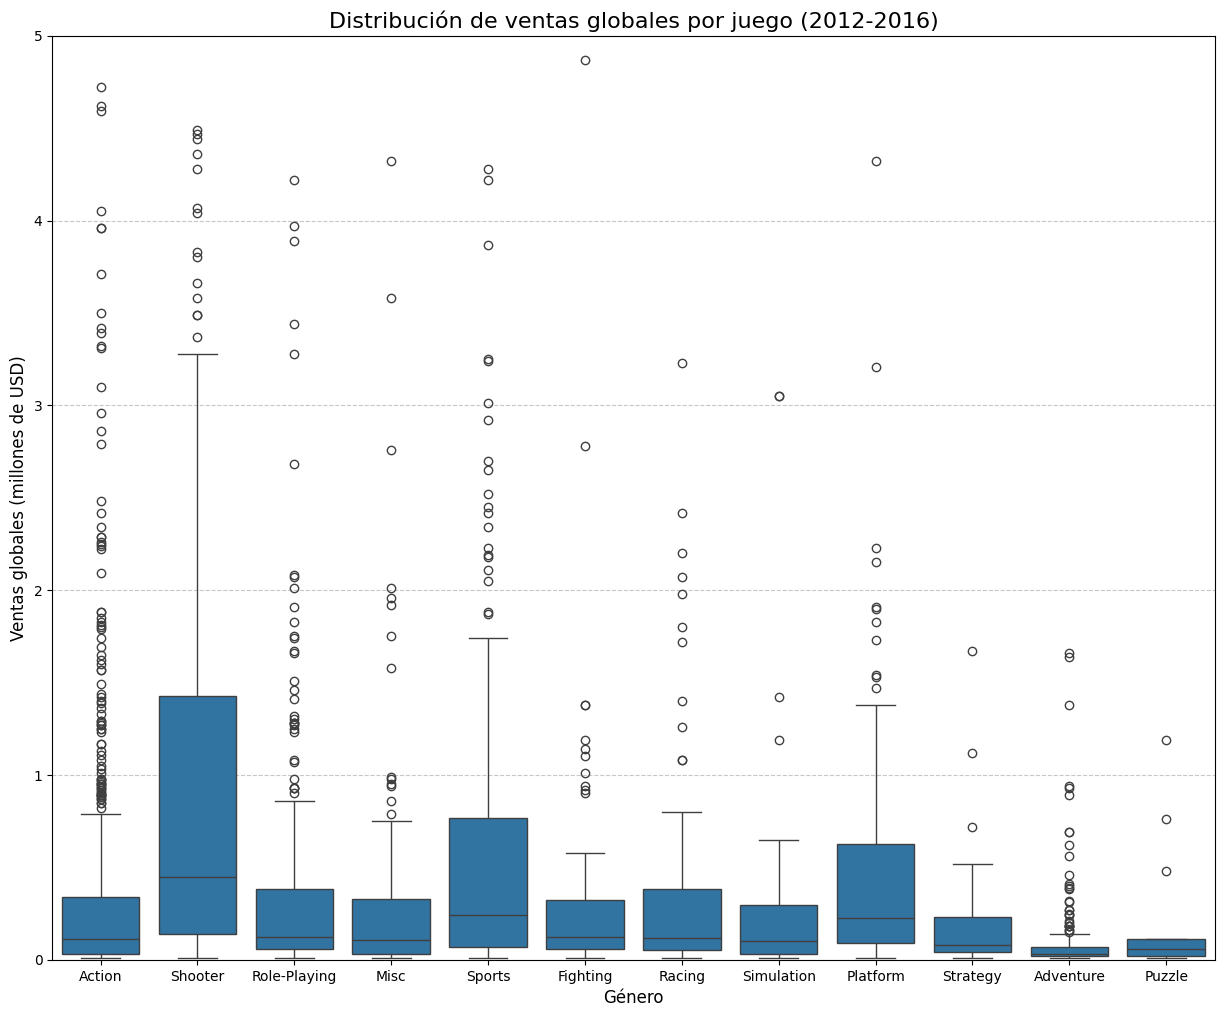

In [249]:
plot.figure(figsize=(15,12))

sns.boxplot(data=set_platforms_projection_in_2017, x='genre', y='total_sales')
plot.ylim(0,5)
plot.title('Distribución de ventas globales por juego (2012-2016)', fontsize=16)
plot.xlabel('Género', fontsize=12)
plot.ylabel('Ventas globales (millones de USD)', fontsize=12)
plot.grid(axis='y', linestyle='--', alpha=0.7)
plot.show()

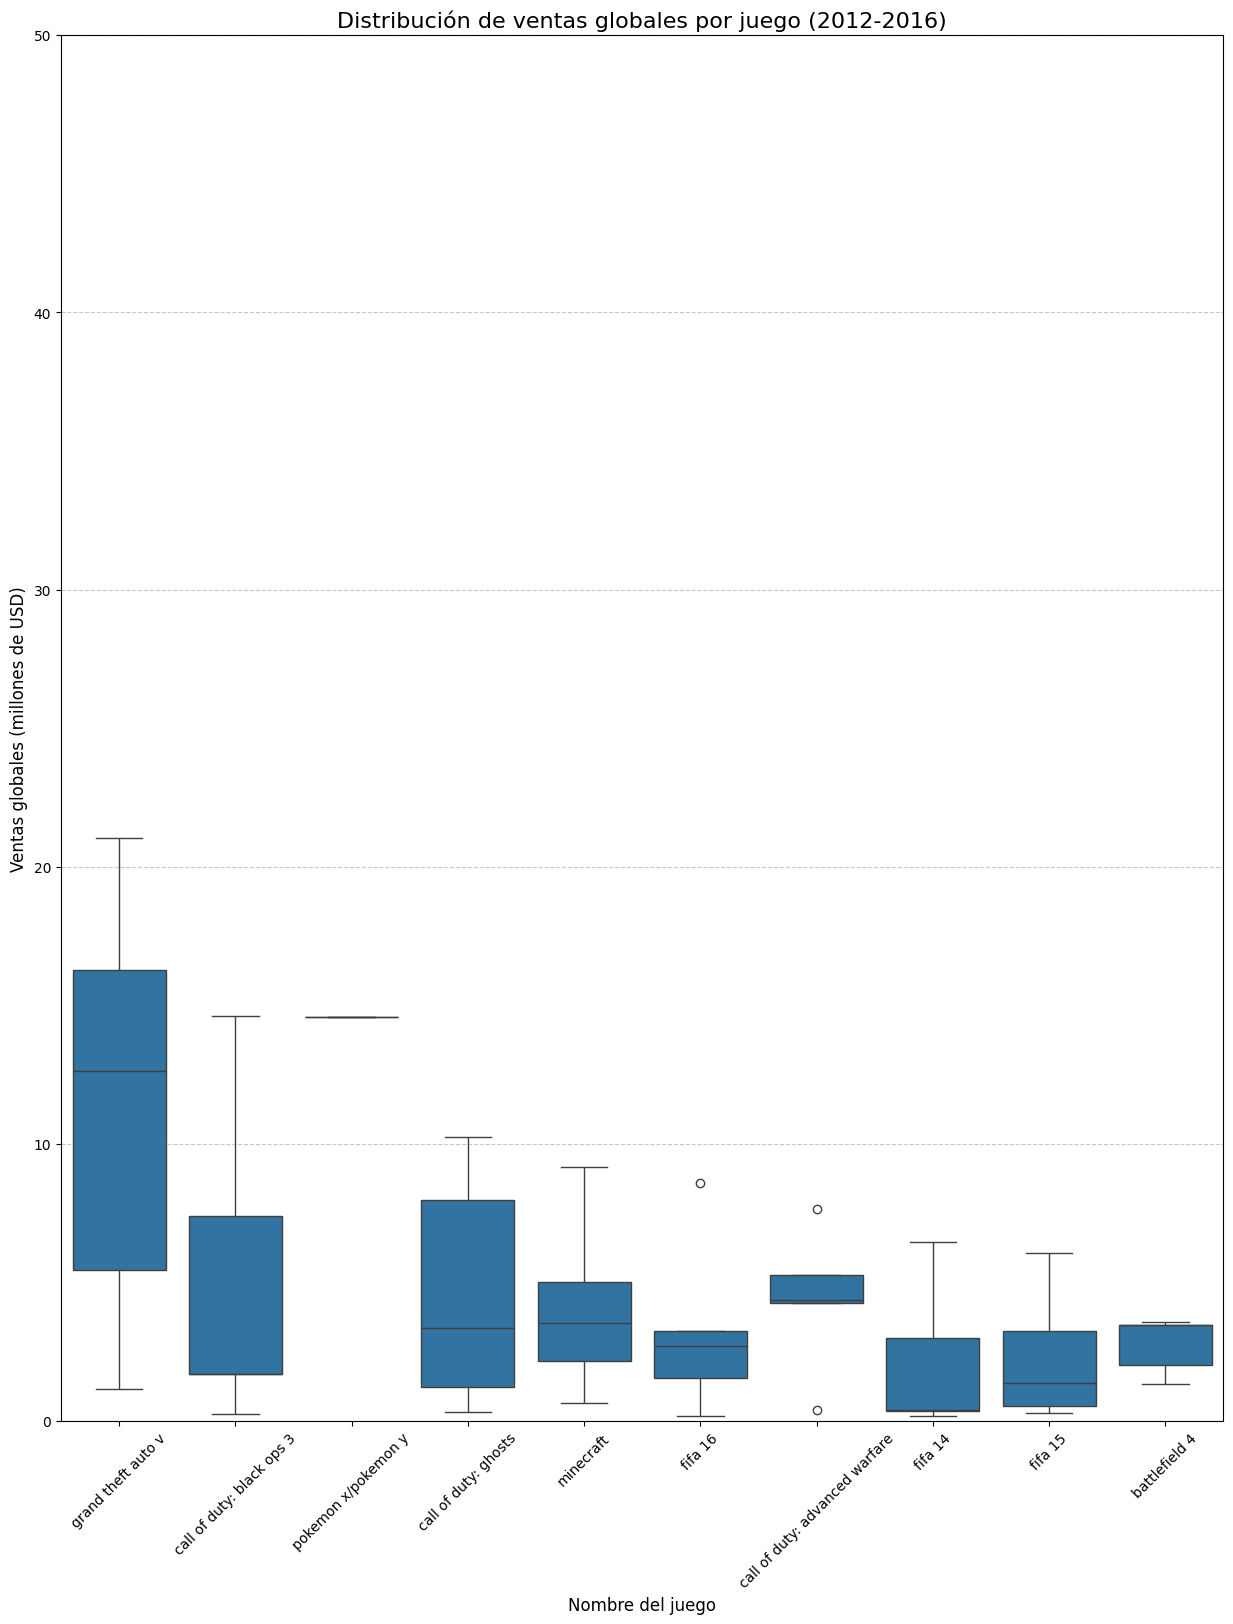

In [260]:
# Creando el diagrama de caja para los datos de las ventas globales de cada juego por nombre del juego
top_ten_titles = set_platforms_projection_in_2017.groupby('name')['total_sales'].sum().sort_values(ascending=False).head(10).index

plot.figure(figsize=(15,18))

sns.boxplot(data=set_platforms_projection_in_2017[set_platforms_projection_in_2017['name'].isin(top_ten_titles)], x='name', y='total_sales')
plot.ylim(0,50)
plot.title('Distribución de ventas globales por juego (2012-2016)', fontsize=16)
plot.xlabel('Nombre del juego', fontsize=12)
plot.ylabel('Ventas globales (millones de USD)', fontsize=12)
plot.xticks(rotation=45)
plot.grid(axis='y', linestyle='--', alpha=0.7)
plot.show()

Los juegos con más rentabilidad son los de acción, deportes, shooter y aventura. Estos géneros tienen una mediana de ventas más alta que el resto. Sin embargo, no se puede generalizar acerca de los géneros con ventas altas y bajas, ya que hay juegos de todos los géneros que han tenido éxito y otros que no lo han tenido. Es importante considerar otros factores como la calidad del juego, la plataforma en la que se lanza, el marketing, entre otros.


## Paso 4. Crea un perfil de usuario para cada región

In [251]:
# Crear una función para definir el perfil de usuario de cada región de 2012 a 2016

regions = ['na_sales', 'eu_sales', 'jp_sales']

def create_user_profile(df, regions):
    profile = {}
    for region in regions:
        top_five_platforms= df.groupby('platform')[region].sum().sort_values(ascending=False).head(5).index.tolist()
        top_genres = df.groupby('genre')[region].sum().sort_values(ascending=False).head(5).index.tolist()
        top_titles = df.groupby('name')[region].sum().sort_values(ascending=False).head(5).index.tolist()
        top_rating = df.groupby('rating')[region].sum().sort_values(ascending=False).head(5).index.tolist()
        profile[region] = {'top_platforms': top_five_platforms, 'top_genres': top_genres, 'top_titles': top_titles, 'top_rating': top_rating}
    return profile
user_profiles = create_user_profile(set_platforms_projection_in_2017, regions)
print(json.dumps(user_profiles, indent=4))

{
    "na_sales": {
        "top_platforms": [
            "ps4",
            "xone",
            "x360",
            "ps3",
            "3ds"
        ],
        "top_genres": [
            "Action",
            "Shooter",
            "Sports",
            "Role-Playing",
            "Misc"
        ],
        "top_titles": [
            "grand theft auto v",
            "call of duty: ghosts",
            "call of duty: black ops 3",
            "minecraft",
            "call of duty: advanced warfare"
        ],
        "top_rating": [
            "E",
            "M",
            "E10+",
            "T"
        ]
    },
    "eu_sales": {
        "top_platforms": [
            "ps4",
            "ps3",
            "xone",
            "x360",
            "3ds"
        ],
        "top_genres": [
            "Action",
            "Shooter",
            "Sports",
            "Role-Playing",
            "Racing"
        ],
        "top_titles": [
            "grand theft auto v",
         

Los perfiles de usuario para cada región se pueden crear analizando las ventas por género, plataforma y clasificación por edades. Por ejemplo, en América del Norte, los juegos de acción y deportes son muy populares, mientras que en Europa, los juegos de aventura y rol tienen una gran demanda. En Japón, los juegos de rol y los juegos de lucha son muy populares. Además, es importante considerar la clasificación por edades, ya que en algunas regiones los juegos para adultos pueden tener una mayor demanda que en otras. Al analizar estos factores, se puede crear un perfil de usuario para cada región y adaptar las estrategias de marketing y desarrollo de juegos en consecuencia.

Efectivamente la clasificación por edades es un factor importante a considerar, ya que en algunas regiones los juegos para adultos pueden tener una mayor demanda que en otras. 

## Paso 5. Prueba las siguientes hipótesis:


***— Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.***


In [252]:
alpha = 0.05

xbox_one_user_scores = df.loc[df['platform'] == 'xone']['user_score']
pc_user_scores = df.loc[df['platform'] == 'pc']['user_score']

results= st.ttest_ind(xbox_one_user_scores, pc_user_scores, equal_var=False)


if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.")
else:
    print("No rechazamos la hipótesis nula: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.")

Rechazamos la hipótesis nula: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.


***— Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.***


In [253]:
acction_user_score = df.loc[df['genre'] == 'Action']['user_score']
deportes_user_score = df.loc[df['genre'] == 'Sports']['user_score']

results= st.ttest_ind(acction_user_score, deportes_user_score, equal_var=False)

if results.pvalue < 0.05:
    print('Rechazamos la hipótesis nula, las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.')
else:
    print('No rechazamos la hipótesis nula, las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.')

No rechazamos la hipótesis nula, las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.


##### — Cómo formulaste las hipótesis nula y alternativa.

La hipótesis nula (H0) siempre asume la igualdad. En la posición conservadora no  ha deferencia ente las plataformas Xbox One y PC, ni entre los géneros de Acción y Deportes. La hipótesis alternativa (H1) asume la diferencia entre las plataformas Xbox One y PC, y entre los géneros de Acción y Deportes.


La hipótesis alternativa H1 es lo que queremos probar. En este caso, queremos demostrar que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes, y que las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.


##### — Qué criterio utilizaste para probar las hipótesis y por qué.
En ester caso se utilizó la prueba t student para muestras independientes. Esta prueba es adecuada para comparar las medias de dos grupos independientes, en este caso, las calificaciones promedio de los usuarios para las plataformas Xbox One y PC, y para los géneros de Acción y Deportes. La prueba t nos permite determinar si hay una diferencia estadísticamente significativa entre las medias de los dos grupos, lo que nos ayudará a aceptar o rechazar la hipótesis nula.

#### Paso 6. Escribe la conclusión general

El exito de los video juegos depende de muchos factores, como la calidad del juego, la plataforma en la que se lanza, el marketing, entre otros. Sin embargo, al analizar los datos de ventas y las calificaciones de los usuarios, podemos identificar patrones y tendencias que nos ayudan a entender mejor el mercado de los videojuegos y a tomar decisiones informadas sobre qué juegos desarrollar y cómo comercializarlos. Es importante seguir analizando los datos y adaptando nuestras estrategias en consecuencia para tener éxito en este mercado competitivo.

Se identifico que  PS$ y Xbox One son las plataformas con mayores ventas, y que los géneros de Acción y Deportes son los más populares entre los usuarios. Además, se encontró que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes, y que las calificaciones promedio de los usuarios para los géneros de Acción y Deportes también son diferentes. Estos hallazgos pueden ayudar a la empresa a tomar decisiones informadas sobre qué juegos desarrollar y cómo comercializarlos en el futuro.

El análisis de distribución mostró una clara diferencia entre volumen y rentabilidad. Las plataformas con mayor volumen de ventas no necesariamente son las más rentables. Esto se debe a que algunas plataformas tienen una gran cantidad de juegos que venden poco, mientras que otras plataformas tienen menos juegos pero con ventas más altas. Es importante considerar tanto el volumen como la rentabilidad al tomar decisiones sobre qué plataformas y géneros de juegos desarrollar y comercializar.

El perfil del usuario varia dantescamente entre regiones. En América del Norte, los juegos de acción y deportes son muy populares, mientras que en Europa, los juegos de aventura y rol tienen una gran demanda. En Japón, los juegos de rol y los juegos de lucha son muy populares. Además, es importante considerar la clasificación por edades, ya que en algunas regiones los juegos para adultos pueden tener una mayor demanda que en otras. Al analizar estos factores, se puede crear un perfil de usuario para cada región y adaptar las estrategias de marketing y desarrollo de juegos en consecuencia.

Las pruebas de hipótesis mostraron que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes, y que las calificaciones promedio de los usuarios para los géneros de Acción y Deportes también son diferentes. Esto sugiere que los usuarios tienen preferencias diferentes en cuanto a plataformas y géneros de juegos, lo que puede ser útil para la empresa al tomar decisiones sobre qué juegos desarrollar y cómo comercializarlos en el futuro.

Recomendación estratégica para 2017:

Para maximizar las ventas en 2017, se recomienda enfocarse en desarrollar y comercializar juegos para las plataformas PS4 y Xbox One, ya que son las plataformas con mayores ventas. Además, se recomienda centrarse en los géneros de Acción y Deportes, ya que son los más populares entre los usuarios, asi como la categoría E.